In [2]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
%matplotlib inline



In [3]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[]

In [3]:
train_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/train_augmented/",                                 
    image_size=(299, 299),
    batch_size = 32*5,
    labels="inferred",
    shuffle=False,
    color_mode='grayscale'
    
)


Found 33336 files belonging to 4 classes.


In [4]:
val_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    shuffle=False,
    color_mode='grayscale'
)



Found 2083 files belonging to 4 classes.


In [5]:
test_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/test/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42,
    shuffle=False,
    color_mode='grayscale'
)

Found 2084 files belonging to 4 classes.


In [6]:
from tensorflow.keras.callbacks import Callback
from timeit import default_timer as timer

class TimingCallback(Callback):
    def __init__(self, logs={}):
        self.logs=[]
    def on_epoch_begin(self, epoch, logs={}):
        self.starttime = timer()
    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(timer()-self.starttime)

In [7]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

early_stopping = EarlyStopping(
                                patience=5, # Attendre 5 epochs avant application
                                min_delta=0.01, # si au bout de 5 epochs la fonction de perte ne varie pas de 1%, 
    # que ce soit à la hausse ou à la baisse, on arrête
                                verbose=1, # Afficher à quel epoch on s'arrête
                                mode='min',
                                monitor='val_loss')

reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # si val_loss stagne sur 3 epochs consécutives selon la valeur min_delta
                                    min_delta=0.01,
                                    factor=0.1,  # On réduit le learning rate d'un facteur 0.1
                                    cooldown=4,  # On attend 4 epochs avant de réitérer 
                                    verbose=1)

time_callback = TimingCallback()

In [8]:
# Instanciation des couches
inputs = Input(shape=(299, 299, 1), name="Input")

normalization_layer=Rescaling(1./255)

first_layer = Conv2D(
    filters=32,
    kernel_size=(5, 5),
    padding='valid',
    activation='relu',
    name='conv_layer1',
)

second_layer = MaxPooling2D(
    pool_size=(2, 2),
    name='max_pooling_layer'
)

third_layer = Dropout(rate=0.2)

fourth_layer = Flatten()

fifth_layer = Dense(
    units=128,
    activation='relu',
    name='dense_hidden_layer'
)

output_layer = Dense(
    units=4,
    activation='softmax',
    name='output_layer'
)


In [22]:
# Utilisation des couches
x= normalization_layer(inputs)
x = first_layer(x)
x = second_layer(x)
x = third_layer(x)
x = fourth_layer(x)
x = fifth_layer(x)



# Création du modèle
outputs = output_layer(x)
model = Model(inputs=inputs, outputs=outputs)

In [ ]:


model.compile(loss='sparse_categorical_crossentropy', # fonction de perte
              optimizer='adam',                # algorithme d'optimisation
              metrics=['accuracy'])            # métrique d'évaluation

model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=50,
                          callbacks = [reduce_learning_rate,
                                       early_stopping,
                                       time_callback],
                          shuffle=False) 

model.save('cnn14072026.keras')

Epoch 1/50


In [9]:
train_acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']

NameError: name 'model_history' is not defined

In [13]:
model_history.history['accuracy'].__sizeof__()

104

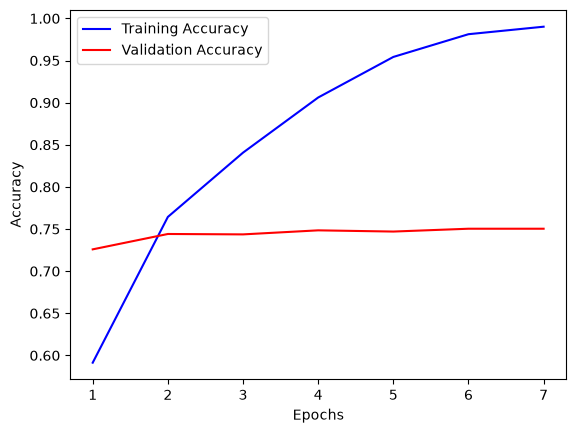

In [14]:
# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 8, 1),
         model_history.history['accuracy'],
         label='Training Accuracy',
         color='blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 , 8, 1),
         model_history.history['val_accuracy'], 
         label='Validation Accuracy',
         color='red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()

In [13]:
model_loaded = load_model('cnn13072026.keras')

# jeu de test
test_pred = model_loaded.predict(test_ds)
test_pred_class = test_pred.argmax(axis=1)
y_true_test_class = np.concatenate([labels for images,labels in test_ds] ,axis=0)

# jeu de validation
val_pred = model_loaded.predict(val_ds)
val_pred_class = val_pred.argmax(axis=1)
y_true_val_class = np.concatenate([labels for images,labels in val_ds] ,axis=0)


66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step


              precision    recall  f1-score   support

           0       0.51      0.39      0.44       337
           1       0.72      0.73      0.72       599
           2       0.80      0.86      0.83      1014
           3       0.99      0.98      0.98       134

    accuracy                           0.75      2084
   macro avg       0.75      0.74      0.74      2084
weighted avg       0.74      0.75      0.75      2084



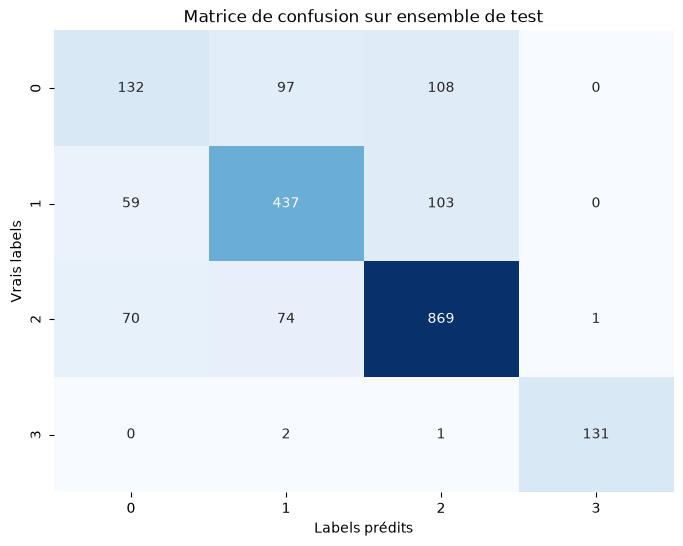

In [ ]:
# Pour avoir le nom des classes (des poissons)
class_names = test_ds.class_names

print(metrics.classification_report(y_true_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_test_class, test_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

              precision    recall  f1-score   support

           0       0.47      0.37      0.42       338
           1       0.73      0.73      0.73       598
           2       0.80      0.86      0.83      1013
           3       1.00      0.96      0.98       134

    accuracy                           0.75      2083
   macro avg       0.75      0.73      0.74      2083
weighted avg       0.74      0.75      0.74      2083



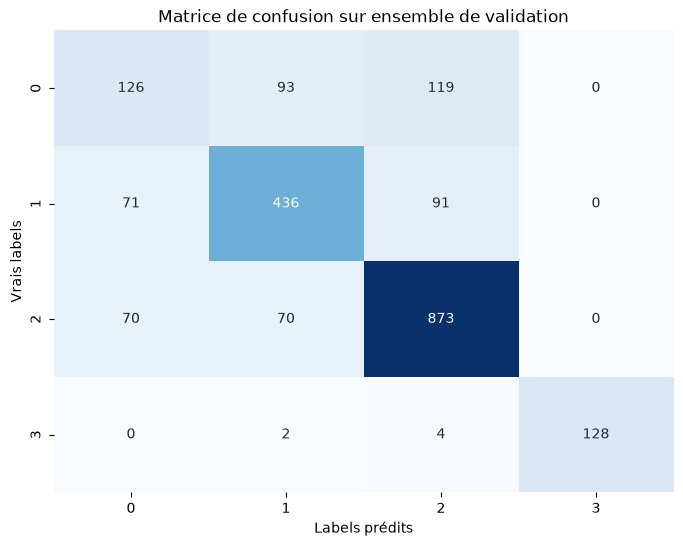

In [15]:
print(metrics.classification_report(y_true_val_class, val_pred_class))


# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_true_val_class, val_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de validation")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

In [ ]:
import tensorflow as tf

def grad_cam(image, model, layer_name):
    # Récupérer la couche convolutive
    layer = model.get_layer(layer_name)
    
    # Créer un modèle qui génère les sorties de la couche convolutive et les prédictions
    grad_model = Model(inputs=model.input, outputs=[layer.output, model.output])

    # Ajout d'une dimension de batch
    image = tf.expand_dims(image, axis=0)

    # Calcul des gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        predicted_class = tf.argmax(predictions[0])  # Classe prédite
        loss = predictions[:, predicted_class]  # Perte pour la classe prédite

    # Gradients des scores par rapport aux sorties de la couche convolutive
    grads = tape.gradient(loss, conv_outputs)

    # Moyenne pondérée des gradients pour chaque canal
    pooled_grads = tf.reduce_mean(grads, axis=(0))

    # Pondération des activations par les gradients calculés
    conv_outputs = conv_outputs[0]  # Supprimer la dimension batch
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalisation de la carte de chaleur
    heatmap = tf.maximum(heatmap, 0)  # Se concentrer uniquement sur les valeurs positives
    heatmap /= tf.math.reduce_max(heatmap)  # Normaliser entre 0 et 1
    heatmap = heatmap.numpy()  # Convertir en tableau numpy pour la visualisation

   # Redimensionner la carte de chaleur pour correspondre à la taille de l'image d'origine
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (image.shape[1], image.shape[2])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1) # supprimer la dimension de taille 1 à la fin du tableau heatmap_resized

    # Colorier la carte de chaleur avec une palette (par exemple, "jet")
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :1] # Récupérer les canaux R, G, B 

    superimposed_image = heatmap_colored * 0.7 + image[0].numpy() / 255.0

    return np.clip(superimposed_image, 0, 1), predicted_class


In [ ]:
def show_grad_cam_cnn(images, model):
    number_of_images = images.shape[0]
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, Conv2D)]

    plt.figure(figsize=(16,16))

    for j, layer in enumerate(conv_layers):

        for i in range(number_of_images):

            subplot_index = i + 1 + j * number_of_images
            plt.subplot(len(conv_layers), number_of_images, subplot_index)

            # Obtenir l'image avec la carte de chaleur superposée
            grad_cam_image, predicted_class = grad_cam(images[i], model, layer)
            
            # Afficher l'image avec Grad-CAM
            plt.title(f'Grad-CAM {layer}')
            plt.imshow(grad_cam_image)
            plt.axis("off")

    plt.show()


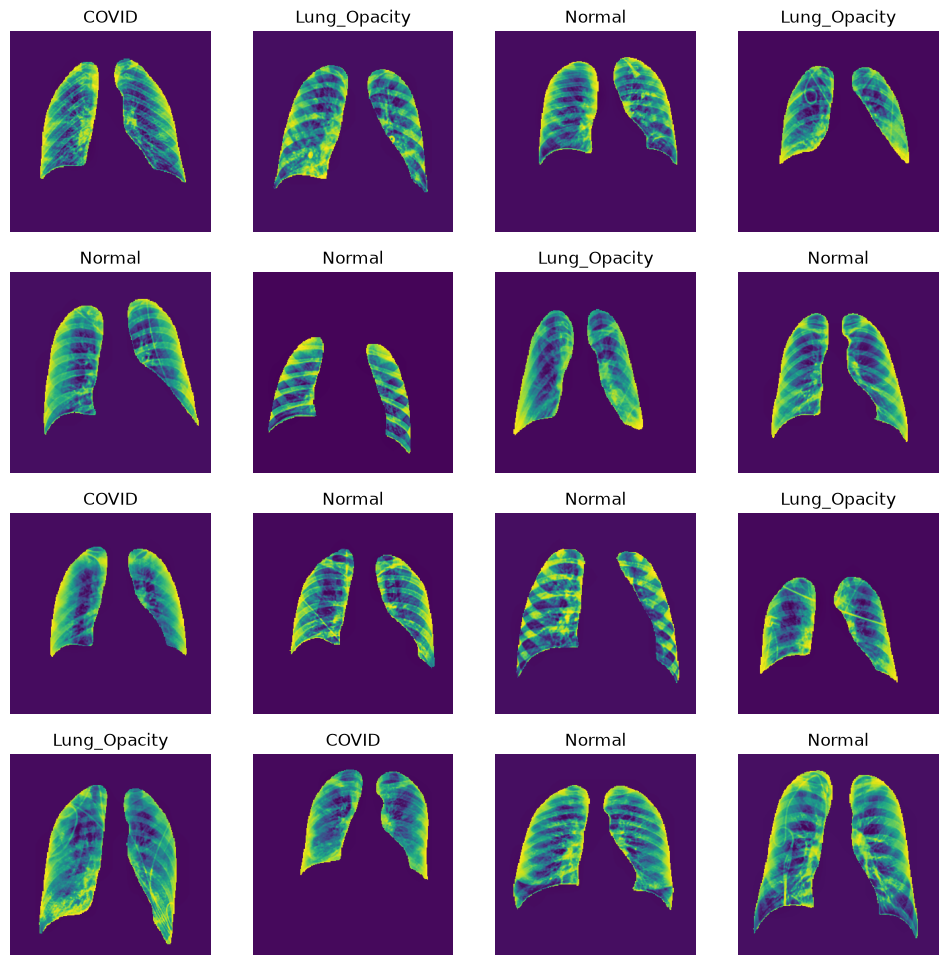

In [ ]:

# Pour avoir le nom des classes (des poissons)
class_names = val_ds.class_names

# Définir le nombre d'images à afficher
number_of_images = 16

# Créer une figure pour l'affichage
plt.figure(figsize=(12,12))

# Obtenir un batch d'images depuis train_ds
for images, labels in val_ds.take(2): 
    # Afficher les images du batch
    for i in range(number_of_images):
        ax = plt.subplot(4, 4, i + 1) 
        plt.imshow(images[i].numpy().astype("uint8")) 
        plt.axis("off") 
        plt.title(f"{class_names[labels[i]]}")
        #plt.title(f"{labels[i]}")

# Afficher les images
plt.show()
